# 1. Setup and Data Preparation
Prepare the runtime environment and load the preprocessed dataset for training.

## Mount Google Drive
Mount Google Drive so the notebook can access the shared dataset archive and any saved outputs.

In [1]:
import sys

# 若在 Colab 環境執行，才掛載 Google Drive
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
else:
    print("非 Colab 環境 (本機執行)，跳過掛載 Google Drive。")

Mounted at /content/drive


## Extract the Dataset Archive
Unzip the preprocessed dataset into the Colab runtime so file access is fast during training and evaluation.

In [2]:
import os
import sys

# 僅在 Colab 環境執行解壓縮
if 'google.colab' in sys.modules:
    # 將雲端硬碟的 .zip 檔解壓縮到 Colab 本地空間 (讀取速度最快)
    zip_path = "/content/drive/MyDrive/Hand_gestures/dataset_v3_processed_detected.zip"
    extract_path = "/content/processed_hagrid_small"

    if os.path.exists(zip_path) and not os.path.exists(extract_path):
        print("解壓縮資料集至 Colab 空間中！ (這會大幅提升訓練速度)...")
        # 加上 -o 參數，如果檔案存在就直接蓋過去，不要跳出詢問視窗卡死
        !unzip -q -o "{zip_path}" -d /content/
        print("解壓縮完成！")
    elif os.path.exists(extract_path):
        print("資料集已解壓縮過了，跳過解壓縮。")
    else:
        print(f"請確認您的雲端硬碟根目錄真的有 {zip_path} 這個檔案！")
else:
    print("本機環境，跳過解壓縮。請確保資料集已經放在正確的資料夾中。")

解壓縮資料集至 Colab 空間中！ (這會大幅提升訓練速度)...
解壓縮完成！


## Load the Manifest Table
Read the CSV manifest and normalize stored file paths so they point to the extracted Colab dataset location.

In [3]:
import pandas as pd
from pathlib import Path

# Colab 測試時的預設解壓縮路徑
DATA_CSV = Path("/content/labels.csv")

if not DATA_CSV.exists():
    # 本機測試時的備用路徑 (Windows / Mac) D:\Hand_Gesture\data\processed_hagrid_small_detect
    DATA_CSV = Path("dataset_v3_processed_detected/labels.csv")
    if not DATA_CSV.exists():
        # 如果還是找不到，可以修改這個絕對路徑 (例如 Windows D 槽)
        DATA_CSV = Path("D:/Hand_Gesture/data/dataset_v2_processed_detected/labels.csv")

df = pd.read_csv(DATA_CSV)

# === 修復路徑：支援各平台 ===
# 無論 CSV 內存的是 Mac 還是 Windows 的絕對路徑
# 統一拿相對結構 "crops/檔名" 組合上目前 CSV 實際所在的資料夾
base_dir = DATA_CSV.parent

def fix_path_cross_platform(path_str):
    if pd.isna(path_str): return path_str
    # 解決 Unix 下讀取 Windows 反斜線會被當成檔名的問題
    path_str = path_str.replace("\\", "/")
    p_path = Path(path_str)
    # 取出 "crops/檔名" 或 "landmarks/檔名"，與真正的 base_dir 結合
    return str(base_dir / p_path.parent.name / p_path.name)

df["crop_path"] = df["crop_path"].apply(fix_path_cross_platform)
df["landmark_path"] = df["landmark_path"].apply(fix_path_cross_platform)

print("using:", DATA_CSV)
print(df.head())
print("total:", len(df))
print(df["label_name"].value_counts())
print(df["label"].value_counts().sort_index())

using: /content/labels.csv
                                                 idx original_class_folder  \
0  take_picture_b1246073-2422-4eb4-a0e4-8fbf046be852          take_picture   
1         peace_8a738072-e2fd-40fe-becf-73e6bb40bcf2                 peace   
2   thumb_index_b2e5c3c8-c3c4-4ff4-9151-2c24a51d1a1d           thumb_index   
3          four_e2ea91a3-60d3-491a-88c9-2e902b136fab                  four   
4            ok_db83a94f-db45-48bf-8555-7a3b25a26e4b                    ok   

   label label_name                                          crop_path  \
0      0        N_A  /content/crops/take_picture_b1246073-2422-4eb4...   
1      0        N_A  /content/crops/peace_8a738072-e2fd-40fe-becf-7...   
2      0        N_A  /content/crops/thumb_index_b2e5c3c8-c3c4-4ff4-...   
3      0        N_A  /content/crops/four_e2ea91a3-60d3-491a-88c9-2e...   
4      3         ok  /content/crops/ok_db83a94f-db45-48bf-8555-7a3b...   

                                       landmark_path qualit

## Split: Training / Validation / Testing
Create stratified train, validation, and test splits so each class keeps a similar distribution across all subsets.

In [4]:
from sklearn.model_selection import train_test_split

SEED = 42

# 如果需要測試用少量樣本，可以取消註解底下這行覆寫：
# df = pd.read_csv("D:/Hand_Gesture/data/processed_sample/labels.csv")

# Split train 70%, temp 30%
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["label"]
)

# Split temp 30% into val 15% and test 15%
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label"]
)

# Reset index for all DataFrames
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("using:", DATA_CSV)
print("train:", len(train_df))
print("val:", len(val_df))
print("test:", len(test_df))

print("\nTrain class count:")
print(train_df["label_name"].value_counts())

print("\nVal class count:")
print(val_df["label_name"].value_counts())

print("\nTest class count:")
print(test_df["label_name"].value_counts())

using: /content/labels.csv
train: 104654
val: 22426
test: 22426

Train class count:
label_name
N_A     55502
palm    10450
ok      10284
fist     9771
like     9397
one      9250
Name: count, dtype: int64

Val class count:
label_name
N_A     11893
palm     2240
ok       2204
fist     2094
like     2013
one      1982
Name: count, dtype: int64

Test class count:
label_name
N_A     11893
palm     2239
ok       2204
fist     2094
like     2014
one      1982
Name: count, dtype: int64


# 2. Image Encoder Preparation
Set up the pretrained image backbone and verify its feature output before multimodal fusion.

In [17]:
# import torch
# import torch.nn as nn
# from torchvision.models import shufflenet_v2_x0_5, ShuffleNet_V2_X0_5_Weights

# 支援跨平台：NVIDIA CUDA (Windows/Linux), Apple MPS (Mac M1/M2), 或是只用 CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("device:", device)

# # load ShuffleNetV2 with pretrained weights on ImageNet
# weights = ShuffleNet_V2_X0_5_Weights.IMAGENET1K_V1
# model = shufflenet_v2_x0_5(weights=weights)

# # ShuffleNetV2 was originally trained on ImageNet with 1000 classes,
# # but we need to adapt it for our 6 classes.
# model.fc = nn.Linear(model.fc.in_features, 6)

# model = model.to(device)

device: cuda


## Check the Runtime Device
Print the installed PyTorch and CUDA information so you can confirm whether training will run on GPU or CPU.

In [5]:
import torch

print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("mps available:", hasattr(torch.backends, "mps") and torch.backends.mps.is_available())
if torch.cuda.is_available():
    print("torch cuda version:", torch.version.cuda)
    print("device count:", torch.cuda.device_count())

torch version: 2.11.0+cu128
cuda available: True
mps available: False
torch cuda version: 12.8
device count: 1


## Define Image Transforms
Install the required libraries and build the image preprocessing pipeline expected by ShuffleNetV2.

In [11]:
import sys
!{sys.executable} -m pip install torch torchvision
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms

# standard transformation for ShuffleNetV2, which expects 224x224 images and normalization with ImageNet's mean and std.
base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_transform = base_transform
val_transform = base_transform
test_transform = base_transform

## Build the Feature Extractor
Build a compact image encoder and verify that each input crop is converted into the expected feature embedding.

In [12]:
import torch
import torch.nn as nn
# from torchvision.models import shufflenet_v2_x0_5, ShuffleNet_V2_X0_5_Weights

# class ShuffleNetV2FeatureExtractor(nn.Module):
#     def __init__(self, output_dim=128):
#         super().__init__()

#         # Start from ImageNet-pretrained ShuffleNetV2_x0_5
#         weights = ShuffleNet_V2_X0_5_Weights.IMAGENET1K_V1
#         self.backbone = shufflenet_v2_x0_5(weights=weights)

#         # Replace the final fully connected layer with an Identity layer
#         # because the input to fc is 1024-D
#         self.backbone.fc = nn.Identity()

#         # Project 1024-D to output_dim
#         self.projector = nn.Sequential(
#             nn.Linear(1024, output_dim),
#             nn.ReLU(),
#             nn.Dropout(0.2)
#         )

#     def forward(self, x):
#         # Input: image tensor of shape [B, 3, H, W]
#         # Output: feature vector of shape [B, output_dim]
#         x = self.backbone(x) # -> [B, 1024]
#         x = self.projector(x) # -> [B, output_dim]
#         return x

## Instantiate the Image Encoder
Create a standalone image encoder module that maps each hand crop into a 128-dimensional representation.

In [ ]:
# Build a standalone image encoder that maps each hand crop to a 128-D feature vector.
# image_encoder = ShuffleNetV2FeatureExtractor(output_dim=128)
# image_encoder = image_encoder.to(device)

## Verify Encoder Output Shapes
Run a single mini-batch through the encoder to confirm the output dimensionality before using it in fusion.

In [ ]:
# # Create a dummy mini-batch and verify that the image encoder produces the expected feature size.
# # Since train_loader is defined later in the fusion section, we use dummy data for now.
# imgs = torch.randn(8, 3, 224, 224).to(device)

# # Use evaluation mode because we only want a forward pass for inspection.
# image_encoder.eval()

# with torch.no_grad():
#     features = image_encoder(imgs)

# print("imgs shape:", imgs.shape)
# print("features shape:", features.shape)

# 3. Fusion Model Training
Combine image and landmark features, then train the multimodal classifier.

In [13]:
class LandmarkOnlyModel(nn.Module):
    def __init__(self, input_dim=42, num_classes=6):
        super().__init__()

        # 加寬並加深： 42 -> 128 -> 128 -> 64 -> 6
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),  # 稍微提高 Dropout 防止加寬後過擬合

            nn.Linear(128, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),

            nn.Linear(64, num_classes)
        )

    def forward(self, landmarks):
        if landmarks.dim() == 3:
            landmarks = landmarks.view(landmarks.size(0), -1)

        logits = self.mlp(landmarks)
        return logits

In [11]:
# import torch
# import torch.nn as nn

# class LandmarkMLP(nn.Module):
#     def __init__(self, input_dim=42, hidden_dim=64, output_dim=128):
#         super().__init__()

#         # The landmark branch encodes 21 (x, y) points into a learned feature vector.
#         self.mlp = nn.Sequential(
#             nn.Linear(input_dim, hidden_dim),
#             nn.ReLU(),
#             # normalizing the activations can help stabilize training and improve generalization,
#             # especially when the input features have varying scales or distributions.
#             nn.BatchNorm1d(hidden_dim),
#             # prevent overfitting by randomly zeroing out 20% of activations during training,
#             # only applied to the first hidden layer since the model is already quite small.
#             nn.Dropout(0.2),

#             nn.Linear(hidden_dim, hidden_dim),
#             nn.ReLU(),
#             nn.BatchNorm1d(hidden_dim),

#             nn.Linear(hidden_dim, output_dim)
#         )

#     def forward(self, landmarks):
#         # Landmarks may arrive as [B, 21, 2] or already flattened as [B, 42].
#         if landmarks.dim() == 3:
#             landmarks = landmarks.view(landmarks.size(0), -1)

#         return self.mlp(landmarks)

# class GestureFusionModel(nn.Module):
#     def __init__(self, image_dim=128, landmark_dim=128, num_classes=6):
#         super().__init__()

#         # Encode image and landmark inputs separately.
#         self.image_encoder = ShuffleNetV2FeatureExtractor(output_dim=image_dim)
#         self.landmark_encoder = LandmarkMLP(output_dim=landmark_dim)

#         # Concatenate both embeddings before classification.
#         fusion_dim = image_dim + landmark_dim

#         self.classifier = nn.Sequential(
#             nn.Linear(fusion_dim, 128),
#             nn.ReLU(),
#             nn.Dropout(0.3),
#             nn.Linear(128, num_classes)
#         )

#     def forward(self, img, landmarks):
#         # image_feature: [B, 128]
#         image_feature = self.image_encoder(img)

#         # landmark_feature: [B, 128]
#         landmark_feature = self.landmark_encoder(landmarks)

#         # fusion_feature: [B, 256]
#         fusion_feature = torch.cat([image_feature, landmark_feature], dim=1)

#         # logits: [B, num_classes]
#         logits = self.classifier(fusion_feature)
#         return logits

## Build the Fusion Dataset
Define a dataset that loads both the cropped image and the landmark array for each sample.

In [23]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import numpy as np
import sys

try:
    from augmentor_landmark import LandmarkOnlyAugmentor
    # from padding_resize import pad_to_square_and_resize
except ModuleNotFoundError as e:
    print(f"\n[錯誤] 無法載入模組: {e}")
    if 'google.colab' in sys.modules:
        print("💡 您目前在 Colab 環境執行。請確保：")
        print("1. 已經將 augmentor_fixed.py, padding_resize.py 上傳到了您的 Google Drive 'Hand_gestures' 資料夾")
        print("2. 或是將這些 .py 檔案上傳到 Colab 左側的 '檔案' (/content) 裡面。")
    else:
        print("💡 您目前在本機執行。請確保 augmentor_fixed.py, padding_resize.py 與本 Notebook 放於同一個資料夾。")
    raise e

class GestureFusionDataset(Dataset):

    def __init__(self, df, transform=None, is_train=True):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.is_train = is_train
        if self.is_train:
            self.augmentor = LandmarkOnlyAugmentor(
                 p_flip=0.5,         # 水平翻轉機率
                 max_rotate=15.0,    # 最大旋轉角度 (正負 15 度)
                 max_scale=0.05,     # 縮放比例 (0.05 代表 0.95x ~ 1.05x)
                 max_translate=0.03, # 平移比例 (相對於手部邊界框的 3%)
                 p_jitter=0.0,       # 骨架抖動機率 (模擬辨識誤差)
                 jitter_std=0.005
                )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ==========================================
        # 🔪 1. 拔除完整圖片讀取，只偷看「標頭」拿寬高
        # ==========================================
        # 用 with 加上 .size，這樣 Python 只會讀取檔案的 meta data，
        # 完全不會把幾十萬個像素解碼到記憶體裡，速度快如閃電！
        with Image.open(row["crop_path"]) as img:
            w, h = img.size

        landmarks = np.load(row["landmark_path"]).astype(np.float32)
        label = int(row["label"])

        # ==========================================
        # 🔪 2. 徹底刪除 pad_to_square_and_resize
        # ==========================================
        # (已刪除)

        # ==========================================
        # 🔪 3. 換成純 Landmark 的增強與比例還原
        # ==========================================
        if self.is_train:
            # 丟給我們剛剛寫好的極速版 LandmarkOnlyAugmentor
            landmarks = self.augmentor(landmarks, w, h)
        else:
            # ⚠️ 關鍵防呆：Validation 雖然不做資料增強，
            # 但依然必須把相對座標乘上寬高轉成真實像素，否則手勢會變形！
            landmarks[:, 0] *= w
            landmarks[:, 1] *= h

        # ==========================================
        # 🔪 4. 徹底刪除 image transform
        # ==========================================
        # (已刪除 if self.transform is not None: ...)

        # ==========================================
        # 5. 保留你原本就寫得很棒的幾何正規化
        # ==========================================
        wrist_coords = landmarks[0, :]
        rel_landmarks = landmarks - wrist_coords
        max_dist = np.max(np.abs(rel_landmarks))
        if max_dist > 0:
            norm_landmarks = rel_landmarks / max_dist

        # Convert to tensors for PyTorch.
        landmarks = torch.tensor(norm_landmarks, dtype=torch.float32)
        label = torch.tensor(label, dtype=torch.long)

        # ==========================================
        # 🔪 6. 霸氣地只回傳兩樣東西！
        # ==========================================
        return landmarks, label

## Create Fusion DataLoaders
Wrap the fusion datasets in DataLoaders so training and evaluation can iterate over mini-batches.

In [25]:
# Build train/validation/test datasets for the fusion model.
train_dataset = GestureFusionDataset(train_df, transform=train_transform, is_train=True)
val_dataset = GestureFusionDataset(val_df, transform=val_transform, is_train=False)
test_dataset = GestureFusionDataset(test_df, transform=val_transform, is_train=False)

# increase batch size since h100 has large memory
BATCH_SIZE = 128

# DataLoader groups samples into mini-batches.
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,           # ⚠️ 關鍵提速參數：讓 4 個 CPU 核心同時幫你做 Data Augmentation
    pin_memory=True,         # ⚠️ 讓 CPU 準備好的資料直接鎖定進 RAM，GPU 讀取瞬間完成
    persistent_workers=True, # 維持 worker 存活，避免每個 Epoch 重新啟動的延遲
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


## Initialize the Fusion Network
Instantiate the full multimodal model and move it onto the selected compute device.

In [18]:
# Create the full fusion model and move it to the selected device.
model = LandmarkOnlyModel(num_classes=6).to(device)

print(model)

LandmarkOnlyModel(
  (mlp): Sequential(
    (0): Linear(in_features=42, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Linear(in_features=64, out_features=6, bias=True)
  )
)


## Sanity Check Fusion Shapes
Pass one batch through the fusion model to confirm that image tensors, landmark tensors, and logits all match the expected shapes.

In [19]:
# Run one batch through the fusion model to verify tensor shapes.
landmarks, labels = next(iter(train_loader))

# imgs = imgs.to(device)
landmarks = landmarks.to(device)

with torch.no_grad():
    logits = model(landmarks)

# print("imgs:", imgs.shape)
print("landmarks:", landmarks.shape)
print("labels:", labels.shape)
print("logits:", logits.shape)

landmarks: torch.Size([128, 21, 2])
labels: torch.Size([128])
logits: torch.Size([128, 6])


## Define Fusion Training Utilities
Implement the training and validation functions used to optimize the multimodal classifier.

In [20]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for landmarks, labels in tqdm(loader, desc="Training", leave=False):
        # imgs 依然會被載入，但我們不把它丟到 device 也不送進模型，以節省資源
        landmarks = landmarks.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        # 這裡只傳入 landmarks
        logits = model(landmarks)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0) # 修正: 使用 labels.size(0) 較精準
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for landmarks, labels in tqdm(loader, desc="Validation", leave=False):
            landmarks = landmarks.to(device)
            labels = labels.to(device)

            # 這裡只傳入 landmarks
            logits = model(landmarks)
            loss = criterion(logits, labels)

            total_loss += loss.item() * labels.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total

In [ ]:
# def train_one_epoch(model, loader):
#     model.train()

#     total_loss = 0
#     correct = 0
#     total = 0

#     for imgs, landmarks, labels in tqdm(loader, desc="Training", leave=False):
#         imgs = imgs.to(device)
#         landmarks = landmarks.to(device)
#         labels = labels.to(device)

#         # Clear old gradients before the next optimization step.
#         optimizer.zero_grad()

#         # Forward pass through the fusion model.
#         logits = model(imgs, landmarks)
#         loss = criterion(logits, labels)

#         # Backpropagation and parameter update.
#         loss.backward()
#         optimizer.step()

#         # Accumulate loss and accuracy statistics for this epoch.
#         total_loss += loss.item() * imgs.size(0)

#         # The predicted class is the one with the highest logit score.
#         preds = logits.argmax(dim=1)
#         correct += (preds == labels).sum().item()
#         total += labels.size(0)

#     return total_loss / total, correct / total


# def evaluate(model, loader):
#     model.eval()

#     total_loss = 0
#     correct = 0
#     total = 0

#     # Disable gradient tracking during validation to save memory and compute.
#     with torch.no_grad():
#         for imgs, landmarks, labels in tqdm(loader, desc="Validation", leave=False):
#             imgs = imgs.to(device)
#             landmarks = landmarks.to(device)
#             labels = labels.to(device)

#             logits = model(imgs, landmarks)
#             loss = criterion(logits, labels)

#             total_loss += loss.item() * imgs.size(0)

#             preds = logits.argmax(dim=1)
#             correct += (preds == labels).sum().item()
#             total += labels.size(0)

#     return total_loss / total, correct / total

## Train and Save the Fusion Model
Run the multimodal training loop, monitor validation accuracy, and keep the best checkpoint.

In [21]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [26]:
import platform
from pathlib import Path
import torch.optim as optim
from tqdm.notebook import tqdm

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=2e-4, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

# === 設定模型儲存路徑 (支援跨平台防呆) ===
if 'google.colab' in sys.modules:
    # Colab 環境：直接存到 Google Drive 裡面，避免資源重置後模型遺失
    save_dir = Path("/content/models")
elif platform.system() == "Windows":
    # Windows 環境：預設存到 D 槽，如果找不到路徑可自行修改這邊
    save_dir = Path("D:/Hand_Gesture/model")
else:
    # Mac / Linux 本機環境：直接存於專案根目錄下的 models 資料夾
    save_dir = Path("./model")

save_dir.mkdir(parents=True, exist_ok=True)
save_path = save_dir / "fusion_shufflenetv2_landmark_augv3_15k_detect_80ep_best.pth"

best_val_acc = 0.0
num_epochs = 30

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")

    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = evaluate(model, val_loader)

    print(
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
    )

    # Keep only the checkpoint with the highest validation accuracy.
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), save_path)
        print(f"Saved best model: val_acc={best_val_acc:.4f}")
    scheduler.step(val_acc)

print("\nBest validation accuracy:", best_val_acc)
print("Best model saved to:", save_path)


Epoch 1/30


Training:   0%|          | 0/817 [00:00<?, ?it/s]

Validation:   0%|          | 0/176 [00:00<?, ?it/s]

train_loss=0.3065, train_acc=0.9307, val_loss=0.1236, val_acc=0.9703
Saved best model: val_acc=0.9703

Epoch 2/30


Training:   0%|          | 0/817 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/176 [00:00<?, ?it/s]

train_loss=0.0950, train_acc=0.9722, val_loss=0.0784, val_acc=0.9765

Epoch 30/30


Training:   0%|          | 0/817 [00:00<?, ?it/s]

Validation:   0%|          | 0/176 [00:00<?, ?it/s]

train_loss=0.0964, train_acc=0.9718, val_loss=0.0776, val_acc=0.9768

Best validation accuracy: 0.976946401498261
Best model saved to: /content/models/fusion_shufflenetv2_landmark_augv3_15k_detect_80ep_best.pth


## SVD

In [ ]:
import torch
import torch.nn as nn

class LowRankLinear(nn.Module):
    def __init__(self, in_features, out_features, rank, bias=True):
        super().__init__()

        self.fc1 = nn.Linear(in_features, rank, bias=False)
        self.fc2 = nn.Linear(rank, out_features, bias=bias)

    def forward(self, x):
        return self.fc2(self.fc1(x))

class ShuffleNetV2FeatureExtractorLowRank(nn.Module):
    def __init__(self, output_dim=128, projector_rank=32):
        super().__init__()

        self.backbone = shufflenet_v2_x0_5(weights=None)
        self.backbone.fc = nn.Identity()

        self.projector = nn.Sequential(
            LowRankLinear(1024, output_dim, rank=projector_rank),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.projector(x)
        return x

class GestureFusionModelLowRank(nn.Module):
    def __init__(
        self,
        image_dim=128,
        landmark_dim=128,
        num_classes=6,
        projector_rank=64,
        classifier_rank=64
    ):
        super().__init__()

        self.image_encoder = ShuffleNetV2FeatureExtractorLowRank(
            output_dim=image_dim,
            projector_rank=projector_rank
        )

        self.landmark_encoder = LandmarkMLP(
            input_dim=42,
            hidden_dim=64,
            output_dim=landmark_dim
        )

        fusion_dim = image_dim + landmark_dim

        self.classifier = nn.Sequential(
            LowRankLinear(fusion_dim, 128, rank=classifier_rank),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, img, landmarks):
        image_feature = self.image_encoder(img)
        landmark_feature = self.landmark_encoder(landmarks)

        fusion_feature = torch.cat([image_feature, landmark_feature], dim=1)

        logits = self.classifier(fusion_feature)
        return logits

In [ ]:
def init_lowrank_from_linear(old_linear, new_lowrank, rank):
    """
    old_linear: nn.Linear(in_features, out_features)
    new_lowrank: LowRankLinear(in_features, out_features, rank)
    """
    W = old_linear.weight.data.clone()  # [out_features, in_features]
    b = old_linear.bias.data.clone() if old_linear.bias is not None else None

    # SVD: W ≈ U_r @ diag(S_r) @ Vh_r
    U, S, Vh = torch.linalg.svd(W, full_matrices=False)

    U_r = U[:, :rank]          # [out, rank]
    S_r = S[:rank]             # [rank]
    Vh_r = Vh[:rank, :]        # [rank, in]

    sqrt_S = torch.sqrt(S_r)

    # W ≈ (U_r * sqrt(S)) @ (sqrt(S) * Vh_r)
    W2 = U_r * sqrt_S.unsqueeze(0)      # [out, rank]
    W1 = sqrt_S.unsqueeze(1) * Vh_r     # [rank, in]

    new_lowrank.fc1.weight.data.copy_(W1)
    new_lowrank.fc2.weight.data.copy_(W2)

    if b is not None:
        new_lowrank.fc2.bias.data.copy_(b)

In [ ]:
from pathlib import Path
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

old_path = Path("/content/models/fusion_shufflenetv2_landmark_augv3_15k_detect_80ep_best.pth")

# 這個要是你原本 full model 的 class
old_model = GestureFusionModel(
    image_dim=128,
    landmark_dim=128,
    num_classes=6
).to(device)

old_model.load_state_dict(torch.load(old_path, map_location=device))
old_model.eval()

# 建立 low-rank model
projector_rank = 64
classifier_rank = 64

lowrank_model = GestureFusionModelLowRank(
    image_dim=128,
    landmark_dim=128,
    num_classes=6,
    projector_rank=projector_rank,
    classifier_rank=classifier_rank
).to(device)

# 1. 複製 ShuffleNet backbone
lowrank_model.image_encoder.backbone.load_state_dict(
    old_model.image_encoder.backbone.state_dict()
)

# 2. SVD 分解 image projector Linear(1024 -> 128)
init_lowrank_from_linear(
    old_linear=old_model.image_encoder.projector[0],
    new_lowrank=lowrank_model.image_encoder.projector[0],
    rank=projector_rank
)

# 3. landmark branch 先完整複製
lowrank_model.landmark_encoder.load_state_dict(
    old_model.landmark_encoder.state_dict()
)

# 4. SVD 分解 classifier 第一層 Linear(256 -> 128)
init_lowrank_from_linear(
    old_linear=old_model.classifier[0],
    new_lowrank=lowrank_model.classifier[0],
    rank=classifier_rank
)

# 5. 最後分類層 Linear(128 -> 6) 直接複製
lowrank_model.classifier[3].load_state_dict(
    old_model.classifier[3].state_dict()
)

print("Low-rank model initialized by SVD.")

Low-rank model initialized by SVD.


In [ ]:
from pathlib import Path
import torch

save_dir = Path("/content/models")
save_dir.mkdir(exist_ok=True)

lowrank_fp16_path = save_dir / "fusion_shufflenetv2_landmark_augv3_15k_detect_80ep_best_SVD.pth"

def save_model_fp16(model, save_path):
    state_dict = model.state_dict()

    state_dict_fp16 = {}

    for k, v in state_dict.items():
        if torch.is_floating_point(v):
            state_dict_fp16[k] = v.half()
        else:
            state_dict_fp16[k] = v

    torch.save(state_dict_fp16, save_path)

save_model_fp16(lowrank_model, lowrank_fp16_path)

print("saved:", lowrank_fp16_path)
print("lowrank fp16 size:", f"{lowrank_fp16_path.stat().st_size / (1024 ** 2):.2f} MB")

saved: /content/models/fusion_shufflenetv2_landmark_augv3_15k_detect_80ep_best_SVD.pth
lowrank fp16 size: 1.03 MB


In [ ]:
from pathlib import Path
import torch

save_dir = Path("/content/models")
save_dir.mkdir(exist_ok=True)

def save_model_fp16(model, save_path):
    state_dict = model.state_dict()
    state_dict_fp16 = {}

    for k, v in state_dict.items():
        if torch.is_floating_point(v):
            state_dict_fp16[k] = v.half()
        else:
            state_dict_fp16[k] = v

    torch.save(state_dict_fp16, save_path)

def count_params(model):
    return sum(p.numel() for p in model.parameters())

for rank in [96, 64, 32, 16]:
    lowrank_model = GestureFusionModelLowRank(
        image_dim=128,
        landmark_dim=128,
        num_classes=6,
        projector_rank=rank,
        classifier_rank=rank
    ).to(device)

    # copy backbone
    lowrank_model.image_encoder.backbone.load_state_dict(
        old_model.image_encoder.backbone.state_dict()
    )

    # SVD init image projector
    init_lowrank_from_linear(
        old_linear=old_model.image_encoder.projector[0],
        new_lowrank=lowrank_model.image_encoder.projector[0],
        rank=rank
    )

    # copy landmark encoder
    lowrank_model.landmark_encoder.load_state_dict(
        old_model.landmark_encoder.state_dict()
    )

    # SVD init classifier first layer
    init_lowrank_from_linear(
        old_linear=old_model.classifier[0],
        new_lowrank=lowrank_model.classifier[0],
        rank=rank
    )

    # copy final classifier
    lowrank_model.classifier[3].load_state_dict(
        old_model.classifier[3].state_dict()
    )

    save_path = save_dir / f"fusion_shufflenetv2_lowrank_r{rank}_fp16.pth"
    save_model_fp16(lowrank_model, save_path)

    print(
        f"rank={rank}, "
        f"params={count_params(lowrank_model)/1e6:.3f} M, "
        f"size={save_path.stat().st_size/(1024**2):.2f} MB"
    )

rank=96, params=0.506 M, size=1.10 MB
rank=64, params=0.457 M, size=1.01 MB
rank=32, params=0.407 M, size=0.92 MB
rank=16, params=0.383 M, size=0.87 MB


# 4. Evaluation and Results
Evaluate the trained model on the test set and summarize model quality and size.

In [30]:
import torch
import pandas as pd
import numpy as np

class_names = ["N_A", "fist", "like", "ok", "one", "palm"]

def evaluate_detailed(model, loader, criterion=None, threshold=None):
    model.eval()

    total_loss = 0.0
    total = 0

    all_labels = []
    all_preds = []
    all_confs = []

    with torch.no_grad():
        for landmarks, labels in loader:
            # imgs = imgs.to(device)
            landmarks = landmarks.to(device)
            labels = labels.to(device)

            logits = model(landmarks)

            # Optionally compute the average loss over the evaluation set.
            if criterion is not None:
                loss = criterion(logits, labels)
                total_loss += loss.item() * imgs.size(0)

            probs = torch.softmax(logits, dim=1)
            confs, preds = torch.max(probs, dim=1)

            # If a confidence threshold is provided, low-confidence predictions
            # are reassigned to the N_A class.
            if threshold is not None:
                preds = torch.where(
                    confs < threshold,
                    torch.zeros_like(preds),
                    preds
                )

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_confs.extend(confs.cpu().numpy())

            total += labels.size(0)

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_confs = np.array(all_confs)

    # Overall accuracy across all classes.
    accuracy = (all_labels == all_preds).mean()

    # Separate the target gesture classes from the N_A class.
    target_mask = all_labels != 0
    na_mask = all_labels == 0

    # Accuracy measured only on non-N_A classes.
    target_accuracy = (
        (all_labels[target_mask] == all_preds[target_mask]).mean()
        if target_mask.sum() > 0 else 0
    )

    # How often N_A samples are incorrectly predicted as a gesture class.
    na_false_trigger_rate = (
        (all_preds[na_mask] != 0).mean()
        if na_mask.sum() > 0 else 0
    )

    avg_loss = total_loss / total if criterion is not None else None

    metrics = {
        "loss": avg_loss,
        "accuracy": accuracy,
        "target_accuracy": target_accuracy,
        "na_false_trigger_rate": na_false_trigger_rate,
    }

    # Store per-sample prediction results for later inspection.
    result_df = pd.DataFrame({
        "true": all_labels,
        "pred": all_preds,
        "confidence": all_confs,
        "true_name": [class_names[i] for i in all_labels],
        "pred_name": [class_names[i] for i in all_preds],
    })

    cm = pd.crosstab(
        result_df["true_name"],
        result_df["pred_name"],
        rownames=["True"],
        colnames=["Pred"],
        dropna=False
    )

    # Reindex to ensure the confusion matrix always shows all 6 classes.
    cm = cm.reindex(index=class_names, columns=class_names, fill_value=0)

    return metrics, cm, result_df

## Inspect Evaluation Outputs
Display the summary metrics, confusion matrix, and a few prediction examples for manual review.

In [31]:
# Run detailed evaluation on the test set and inspect both summary metrics and examples.
model = model.float()
metrics, cm, result_df = evaluate_detailed(
    model,
    test_loader,
    criterion=criterion,
    threshold=None
)

print(metrics)
display(cm)
display(result_df.head())

NameError: name 'imgs' is not defined

### Test low rank

In [29]:
from pathlib import Path
import torch
import torch.nn as nn

rank = 16

model_path = Path("/content/models/fusion_shufflenetv2_lowrank_r16_fp16.pth")

model = GestureFusionModelLowRank(
    image_dim=128,
    landmark_dim=128,
    num_classes=6,
    projector_rank=rank,
    classifier_rank=rank
).to(device)

state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)

model = model.to(device)
model.eval()

criterion = nn.CrossEntropyLoss()

metrics, cm, result_df = evaluate_detailed(
    model,
    val_loader,
    criterion=criterion,
    threshold=None
)

print(metrics)
display(cm)

NameError: name 'GestureFusionModelLowRank' is not defined

## Predict with Heuristic

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.notebook import tqdm

from inference import predict

class_names = ["N_A", "fist", "like", "ok", "one", "palm"]


def evaluate_predict_on_df(df, max_samples=None, random_state=42):
    if max_samples is not None:
        eval_df = df.sample(min(max_samples, len(df)), random_state=random_state).reset_index(drop=True)
    else:
        eval_df = df.reset_index(drop=True)

    results = []

    for row in tqdm(eval_df.itertuples(), total=len(eval_df), desc="Predict testing"):
        crop_path = Path(row.crop_path)
        landmark_path = Path(row.landmark_path)

        crop_img = np.array(Image.open(crop_path).convert("RGB"))
        landmarks = np.load(landmark_path)

        pred = predict(crop_img, landmarks)
        true = int(row.label)

        results.append({
            "true": true,
            "true_name": class_names[true],
            "pred": pred,
            "pred_name": class_names[pred],
            "correct": pred == true,
            "crop_path": str(crop_path),
            "landmark_path": str(landmark_path),
        })

    result_df = pd.DataFrame(results)

    accuracy = result_df["correct"].mean()

    target_df = result_df[result_df["true"] != 0]
    na_df = result_df[result_df["true"] == 0]

    target_accuracy = target_df["correct"].mean() if len(target_df) > 0 else 0
    na_false_trigger_rate = (na_df["pred"] != 0).mean() if len(na_df) > 0 else 0

    metrics = {
        "accuracy": accuracy,
        "target_accuracy": target_accuracy,
        "na_false_trigger_rate": na_false_trigger_rate,
        "total": len(result_df),
    }

    cm = pd.crosstab(
        result_df["true_name"],
        result_df["pred_name"],
        rownames=["True"],
        colnames=["Pred"],
        dropna=False
    )

    cm = cm.reindex(index=class_names, columns=class_names, fill_value=0)

    return metrics, cm, result_df

metrics, cm, result_df = evaluate_predict_on_df(test_df)

print(metrics)
display(cm)
display(result_df.head())

Predict testing:   0%|          | 0/22426 [00:00<?, ?it/s]

{'accuracy': np.float64(0.9800677784714171), 'target_accuracy': np.float64(0.962593752966866), 'na_false_trigger_rate': np.float64(0.004456402926090978), 'total': 22426}


Pred,N_A,fist,like,ok,one,palm
True,,,,,,
N_A,11840,5,18,1,11,18
fist,47,2046,0,0,1,0
like,60,0,1954,0,0,0
ok,119,1,0,2084,0,0
one,49,1,0,0,1932,0
palm,116,0,0,0,0,2123


,true,true_name,pred,pred_name,correct,crop_path,landmark_path
0,3,ok,0,N_A,False,/content/crops/ok_561ef324-d6cf-49ce-8097-60e1...,/content/landmarks/ok_561ef324-d6cf-49ce-8097-...
1,0,N_A,0,N_A,True,/content/crops/like_d78af78f-e009-4c94-822c-c1...,/content/landmarks/like_d78af78f-e009-4c94-822...
2,0,N_A,0,N_A,True,/content/crops/grip_9caaca13-a05e-496b-9449-33...,/content/landmarks/grip_9caaca13-a05e-496b-944...
3,3,ok,0,N_A,False,/content/crops/ok_566e67db-e35b-41df-8e2d-1072...,/content/landmarks/ok_566e67db-e35b-41df-8e2d-...
4,0,N_A,0,N_A,True,/content/crops/fist_bc930e7c-6c9e-4a5c-abe9-fd...,/content/landmarks/fist_bc930e7c-6c9e-4a5c-abe...


## Measure Checkpoint Size
Summarize the saved fusion checkpoint size and the model parameter footprint.

In [ ]:
from pathlib import Path

# Report the saved checkpoint size and the number of model parameters.
file_size_mb = save_path.stat().st_size / (1024 ** 2)

print("Model file:", save_path)
print("Saved .pth size:", f"{file_size_mb:.2f} MB")

num_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

param_size_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
buffer_size_bytes = sum(b.numel() * b.element_size() for b in model.buffers())

model_memory_mb = (param_size_bytes + buffer_size_bytes) / (1024 ** 2)

print("Total parameters:", f"{num_params / 1e6:.3f} M")
print("Trainable parameters:", f"{trainable_params / 1e6:.3f} M")
print("Parameter + buffer size:", f"{model_memory_mb:.2f} MB")

# convert the model to FP16 and save it as a new checkpoint to compare file sizes.
model_fp16 = model.half()

save_path_fp16 = save_path.with_name(save_path.stem + "_fp16.pth")

torch.save(model_fp16.state_dict(), save_path_fp16)

fp16_size_mb = save_path_fp16.stat().st_size / (1024 ** 2)
print(f"原本 FP32 模型大小: {file_size_mb:.2f} MB")
print(f"轉為 FP16 模型大小: {fp16_size_mb:.2f} MB")

Model file: /content/models/fusion_shufflenetv2_lowrank_r16_fp16.pth
Saved .pth size: 0.87 MB
Total parameters: 0.383 M
Trainable parameters: 0.383 M
Parameter + buffer size: 1.49 MB
原本 FP32 模型大小: 0.87 MB
轉為 FP16 模型大小: 0.89 MB


# Compress some model


In [1]:
import torch
from pathlib import Path

# 1. 設定你下載好的原始 .pth 檔案路徑
pth_file_name = "/content/landmark_only.pth"  # ⚠️ 請把這裡換成你的檔案名稱/路徑
original_pth_path = Path(pth_file_name)

if not original_pth_path.exists():
    print(f"找不到檔案: {original_pth_path}，請確認路徑是否正確！")
else:
    # 取得原始檔案大小
    file_size_mb = original_pth_path.stat().st_size / (1024 ** 2)
    print("="*40)
    print(f"📁 讀取權重檔: {original_pth_path}")
    print(f"📦 原本 FP32 檔案大小: {file_size_mb:.2f} MB")

    # 2. 直接讀取權重字典 (state_dict)
    # 加上 map_location='cpu' 確保即使你現在用沒有 GPU 的環境也能順利讀取
    state_dict = torch.load(original_pth_path, map_location='cpu', weights_only=True)

    # 3. 遍歷字典，把所有的浮點數張量 (Float Tensors) 強制轉為 FP16
    fp16_state_dict = {}
    for key, tensor in state_dict.items():
        # 確認它是張量，並且是浮點數型態 (float32 等)
        if torch.is_tensor(tensor) and torch.is_floating_point(tensor):
            fp16_state_dict[key] = tensor.half() # 壓縮為 FP16
        else:
            fp16_state_dict[key] = tensor        # 其他型態(如整數)保持原樣

    # 4. 儲存成新的壓縮版 .pth 檔案
    save_path_fp16 = original_pth_path.with_name(original_pth_path.stem + "_fp16.pth")
    torch.save(fp16_state_dict, save_path_fp16)

    # 取得壓縮後的檔案大小
    fp16_size_mb = save_path_fp16.stat().st_size / (1024 ** 2)
    print("-" * 40)
    print(f"✨ 轉換完成！")
    print(f"📦 轉為 FP16 檔案大小: {fp16_size_mb:.2f} MB")
    print(f"💾 新檔案已儲存至: {save_path_fp16}")
    print("="*40)

📁 讀取權重檔: /content/landmark_only.pth
📦 原本 FP32 檔案大小: 0.13 MB
----------------------------------------
✨ 轉換完成！
📦 轉為 FP16 檔案大小: 0.07 MB
💾 新檔案已儲存至: /content/landmark_only_fp16.pth


## Evaluate FP16 Model (Without Heuristic)
Test the half-precision (FP16) model to see the minimal accuracy drop versus file size reduction.

In [ ]:
# Run detailed evaluation on the test set and inspect both summary metrics and examples.
# 當我們要測試 FP16 模型的準確率時，輸入的圖片與特徵張量也必須轉成 FP16 (.half())！
def evaluate_detailed_fp16(model, loader, criterion=None, threshold=None):
    model.eval()

    total_loss = 0.0
    total = 0

    all_labels = []
    all_preds = []
    all_confs = []

    with torch.no_grad():
        for imgs, landmarks, labels in loader:
            # 關鍵修改：將 input tensor 也轉為 half precision
            imgs = imgs.to(device).half()
            landmarks = landmarks.to(device).half()
            labels = labels.to(device)

            logits = model(imgs, landmarks)

            # Option: 如果要算 loss，要把 logits 也轉回 FP32，或是確保 labels 吻合
            if criterion is not None:
                loss = criterion(logits.float(), labels)
                total_loss += loss.item() * imgs.size(0)

            probs = torch.softmax(logits, dim=1)
            confs, preds = torch.max(probs, dim=1)

            if threshold is not None:
                preds = torch.where(
                    confs < threshold,
                    torch.zeros_like(preds),
                    preds
                )

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_confs.extend(confs.cpu().numpy())

            total += labels.size(0)

    # 後面的指標計算與 FP32 完全相同
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_confs = np.array(all_confs)

    accuracy = (all_labels == all_preds).mean()

    target_mask = all_labels != 0
    na_mask = all_labels == 0

    target_accuracy = (
        (all_labels[target_mask] == all_preds[target_mask]).mean()
        if target_mask.sum() > 0 else 0
    )

    na_false_trigger_rate = (
        (all_preds[na_mask] != 0).mean()
        if na_mask.sum() > 0 else 0
    )

    avg_loss = total_loss / total if criterion is not None else None

    metrics = {
        "loss": avg_loss,
        "accuracy": accuracy,
        "target_accuracy": target_accuracy,
        "na_false_trigger_rate": na_false_trigger_rate,
    }

    result_df = pd.DataFrame({
        "true": all_labels,
        "pred": all_preds,
        "confidence": all_confs,
        "true_name": [class_names[i] for i in all_labels],
        "pred_name": [class_names[i] for i in all_preds],
    })

    cm = pd.crosstab(
        result_df["true_name"],
        result_df["pred_name"],
        rownames=["True"],
        colnames=["Pred"],
        dropna=False
    )
    cm = cm.reindex(index=class_names, columns=class_names, fill_value=0)

    return metrics, cm, result_df

metrics, cm, result_df = evaluate_detailed_fp16(
    model_fp16,
    test_loader,
    criterion=criterion,
    threshold=None
)

print(metrics)
display(cm)
display(result_df.head())

{'loss': 0.07310003273826486, 'accuracy': np.float64(0.9807366449656648), 'target_accuracy': np.float64(0.9650621855121998), 'na_false_trigger_rate': np.float64(0.005381316740940049)}


Pred,N_A,fist,like,ok,one,palm
True,,,,,,
N_A,11829,8,22,1,21,12
fist,47,2045,0,0,2,0
like,56,0,1958,0,0,0
ok,116,1,0,2087,0,0
one,32,1,0,0,1949,0
palm,113,0,0,0,0,2126


/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,true,pred,confidence,true_name,pred_name
0,3,0,0.990234,ok,N_A
1,0,0,0.837891,N_A,N_A
2,0,0,0.999512,N_A,N_A
3,3,0,0.788574,ok,N_A
4,0,0,0.755859,N_A,N_A


## Results Summary
Record the key training and evaluation outcomes for the final report.

KeyError: 'crop_path'

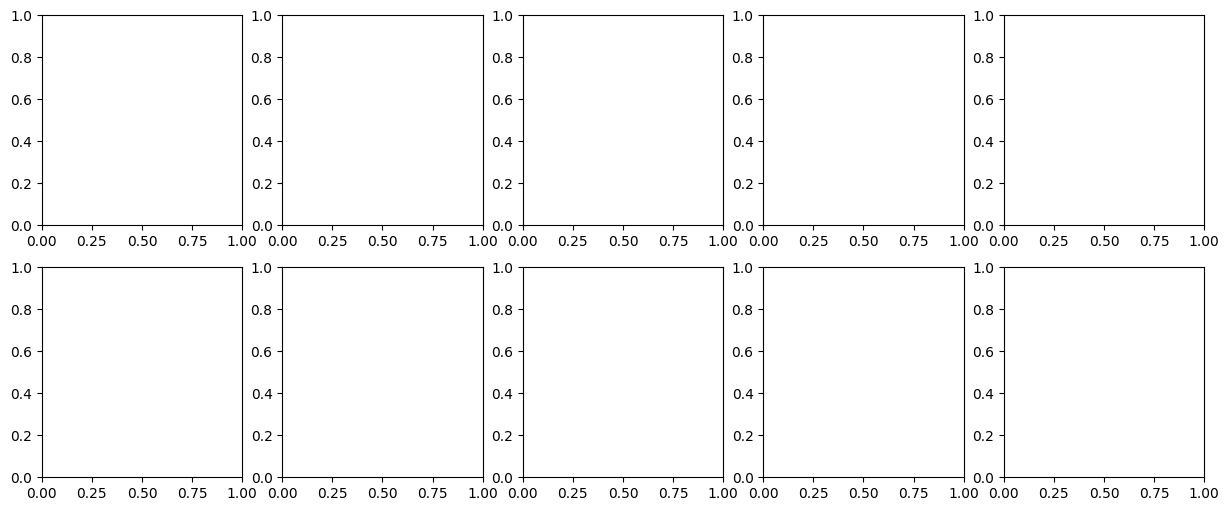

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

# 隨機挑選 10 張被誤判為 N_A (背景/無手勢) 的照片來觀察原因
# True Label 不是 N_A (true != 0)，但被預測成 N_A (pred == 0)
false_na_df = result_df[(result_df['true'] != 0) & (result_df['pred'] == 0)].sample(10, random_state=42)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for idx, (_, row) in enumerate(false_na_df.iterrows()):
    img = Image.open(row['crop_path'])
    axes[idx].imshow(img)
    axes[idx].set_title(f"True: {row['true_name']}\nPred: N_A")
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## Export Misclassifications
Export and zip the incorrectly predicted samples into labeled folders for qualitative analysis (e.g. `True_palm_Pred_NA`).

In [ ]:
import os
import shutil
from pathlib import Path
from tqdm.notebook import tqdm

# 剛剛執行的 evaluate_detailed (純模型) 存在 result_df
result_df_pure = result_df.copy()
# 因為 test_loader 設定 shuffle=False，所以順序會跟 test_df 完全一致，可以直接把路徑貼過來
result_df_pure['crop_path'] = test_df['crop_path'].values

# 設定匯出的主資料夾
EXPORT_DIR = Path("./error_analysis_shuf")
if 'google.colab' in sys.modules:
    EXPORT_DIR = Path("/content/error_analysis_shuf")

def export_errors_to_folders(df, subfolder_name):
    # 篩選出所有預測錯誤的樣本 (True 不等於 Pred)
    error_df = df[df['true'] != df['pred']]

    base_out_dir = EXPORT_DIR / subfolder_name

    print(f"正在匯出 {subfolder_name} 的錯誤圖片，共 {len(error_df)} 張...")
    for _, row in tqdm(error_df.iterrows(), total=len(error_df)):
        true_name = row['true_name']
        pred_name = row['pred_name']

        # 建立分類原因的資料夾，例如 "True_palm_Pred_NA"
        category_dir = base_out_dir / f"True_{true_name}_Pred_{pred_name}"
        category_dir.mkdir(parents=True, exist_ok=True)

        # 複製圖片過去
        src_path = Path(row['crop_path'])
        if src_path.exists():
            dst_path = category_dir / src_path.name
            shutil.copy2(src_path, dst_path)

# 首先匯出「純模型 (Pure Model)」的錯誤
export_errors_to_folders(result_df_pure, "pure_model_errors")

正在匯出 pure_model_errors 的錯誤圖片，共 432 張...


  0%|          | 0/432 [00:00<?, ?it/s]

In [ ]:
# 剛剛跑完 heuristic 的預測結果現在已經在 result_df 中了
result_df_heuristic = result_df.copy()

# 由於 evaluate_predict_on_df 已經把 crop_path 記錄在 result_df 裡面，我們可以直接匯出
export_errors_to_folders(result_df_heuristic, "heuristic_errors_shuf")

# 若要在 Colab 上直接下載，可以打包成 zip
if 'google.colab' in sys.modules:
    print("\n[Colab 環境] 正在將分類錯誤的資料夾打包成 ZIP 檔...")
    import shutil
    shutil.make_archive("/content/error_analysis_shuf", 'zip', "/content/error_analysis_shuf")
    print("打包完成，可以在 Colab 左側的 '檔案' 列表中找到 error_analysis_shuf.zip 並按右鍵下載")
else:
    print(f"\n[本機環境] 分類完成！請到 {EXPORT_DIR.absolute()} 裡面查看。")

正在匯出 heuristic_errors_shuf 的錯誤圖片，共 432 張...


  0%|          | 0/432 [00:00<?, ?it/s]

KeyError: 'crop_path'

In [ ]:
!zip -r models_v3aug_baldataset.zip models

  adding: models/ (stored 0%)
  adding: models/fusion_shufflenetv2_landmark_augv3_15k_detect_80ep_best_SVD.pth (deflated 18%)
  adding: models/fusion_shufflenetv2_lowrank_r96_fp16.pth (deflated 16%)
  adding: models/fusion_shufflenetv2_lowrank_r64_fp16.pth (deflated 16%)
  adding: models/fusion_shufflenetv2_lowrank_r16_fp16.pth (deflated 18%)
  adding: models/fusion_shufflenetv2_landmark_augv3_15k_detect_80ep_best.pth (deflated 12%)
  adding: models/fusion_shufflenetv2_lowrank_r32_fp16.pth (deflated 17%)


In [ ]:
from google.colab import files
files.download('models_v3aug_baldataset.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>